# Face Mask Detection - Deep Learning Midterm Project

## Face Mask Classification with DenseNet121 & MobileNetV1 (Transfer Learning)

**Requirements:**
- Dataset: Kaggle Face Mask Detection
- Models: DenseNet121 and MobileNetV1 (pre-trained on ImageNet)
- Training: 100 epochs, Early Stopping (patience=25), ReduceLROnPlateau
- Optimizer: Adam (lr=0.001)
- Metrics: Accuracy, Precision, Recall, F1, Specificity, AUC, ROC, Confusion Matrix
- Data Augmentation: Rotation, Shift, Shear, Zoom, Horizontal Flip
- GPU/CPU: Auto-detection via tf.config.list_physical_devices

## 1. Import Libraries & Check GPU

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Dataset download helper
import opendatasets as od

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121, MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, roc_auc_score
)

print('All libraries loaded successfully.')

## 2. GPU / CPU Check

In [2]:
print('=' * 60)
print('CHECKING GPU / CPU...')
print('=' * 60)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPU Available: {len(gpus) > 0}')

if len(gpus) > 0:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth enabled.')
    except RuntimeError as e:
        print(e)

    DEVICE = '/GPU:0'
    print(f'GPU Count: {len(gpus)}')
    print(f'Active GPU: {gpus[0].name}')

    # Enable mixed precision for ~2x speedup on GPU
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision (float16) enabled for GPU acceleration.')
else:
    DEVICE = '/CPU:0'
    print('No GPU found - using CPU.')
    print('Training on CPU will be slower.')

print(f'\nDevice: {DEVICE}')
print(f'TensorFlow Version: {tf.__version__}')
print(f'Keras Version: {keras.__version__}')

CHECKING GPU / CPU...
GPU Available: False
No GPU found - using CPU.
Training on CPU will be slower.

Device: /CPU:0
TensorFlow Version: 2.21.0
Keras Version: 3.14.0


## 3. Configuration Parameters

In [ ]:
# Project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
KAGGLE_DATASET_URL = 'https://www.kaggle.com/datasets/omkargurav/face-mask-dataset'

# Create directories
for directory in [DATA_DIR, MODELS_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Dataset paths. These are resolved again after optional Kaggle download.
WITH_MASK_DIR = DATA_DIR / 'with_mask'
WITHOUT_MASK_DIR = DATA_DIR / 'without_mask'


def getPositiveIntEnv(name, default):
    value = os.environ.get(name)
    if value in (None, ''):
        return default
    try:
        parsed = int(value)
    except ValueError as exc:
        raise ValueError(f'{name} must be a positive integer, got {value!r}') from exc
    if parsed < 1:
        raise ValueError(f'{name} must be a positive integer, got {value!r}')
    return parsed


# Model parameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = getPositiveIntEnv('BATCH_SIZE', 32)
EPOCHS = getPositiveIntEnv('EPOCHS', 100)
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.2
MIN_IMAGES_PER_CLASS = 5

# Training parameters
LEARNING_RATE = 0.001
MOMENTUM = 0.9
EARLY_STOPPING_PATIENCE = 25
REDUCE_LR_PATIENCE = 5
REDUCE_LR_FACTOR = 0.1

# Data augmentation parameters
ROTATION_RANGE = 10
WIDTH_SHIFT_RANGE = 0.1
HEIGHT_SHIFT_RANGE = 0.1
SHEAR_RANGE = 0.1
ZOOM_RANGE = 0.1
HORIZONTAL_FLIP = True
FILL_MODE = 'nearest'

print('Configuration parameters defined.')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')

## 4. Load Dataset

In [ ]:
print('
' + '=' * 60)
print('LOADING DATA...')
print('=' * 60)

supportedExtensions = {'.jpg', '.jpeg', '.png'}
KAGGLE_JSON_PATH = Path.home() / '.kaggle' / 'kaggle.json'


def hasKaggleCredentials():
    hasEnvCredentials = bool(os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'))
    return hasEnvCredentials or KAGGLE_JSON_PATH.exists()


def findClassDirectory(root, folderName):
    direct = root / folderName
    candidates = []
    if direct.is_dir():
        candidates.append(direct)
    candidates.extend(
        path for path in root.rglob(folderName)
        if path.is_dir() and path != direct
    )
    if not candidates:
        return None
    return sorted(candidates, key=lambda path: (len(path.parts), str(path).lower()))[0]


def resolveDatasetDirectories():
    withMaskDir = findClassDirectory(DATA_DIR, 'with_mask')
    withoutMaskDir = findClassDirectory(DATA_DIR, 'without_mask')
    if withMaskDir and withoutMaskDir:
        return withMaskDir, withoutMaskDir

    if not hasKaggleCredentials():
        raise RuntimeError(
            'Dataset folders were not found and Kaggle credentials are not configured.
'
            f'Expected folders: {DATA_DIR / "with_mask"} and {DATA_DIR / "without_mask"}
'
            'To enable automatic download, set KAGGLE_USERNAME and KAGGLE_KEY, '
            f'or place kaggle.json at {KAGGLE_JSON_PATH}.
'
            f'Dataset URL: {KAGGLE_DATASET_URL}'
        )

    print('Dataset folders not found. Downloading from Kaggle...')
    od.download(KAGGLE_DATASET_URL, data_dir=str(DATA_DIR))

    withMaskDir = findClassDirectory(DATA_DIR, 'with_mask')
    withoutMaskDir = findClassDirectory(DATA_DIR, 'without_mask')
    if not (withMaskDir and withoutMaskDir):
        raise RuntimeError(
            'Kaggle download finished, but class folders were not found under data/.
'
            'Please verify that the dataset contains with_mask and without_mask folders.'
        )
    return withMaskDir, withoutMaskDir


def collectImagePaths(classDir):
    return sorted(
        str(path) for path in classDir.rglob('*')
        if path.is_file() and path.suffix.lower() in supportedExtensions
    )


WITH_MASK_DIR, WITHOUT_MASK_DIR = resolveDatasetDirectories()
withMaskPaths = collectImagePaths(WITH_MASK_DIR)
withoutMaskPaths = collectImagePaths(WITHOUT_MASK_DIR)

print(f'With mask ({WITH_MASK_DIR}): {len(withMaskPaths)} images')
print(f'Without mask ({WITHOUT_MASK_DIR}): {len(withoutMaskPaths)} images')

if len(withMaskPaths) < MIN_IMAGES_PER_CLASS or len(withoutMaskPaths) < MIN_IMAGES_PER_CLASS:
    raise RuntimeError(
        'Not enough images to create stratified train/validation/test splits.
'
        f'Minimum per class: {MIN_IMAGES_PER_CLASS}
'
        f'Found with_mask={len(withMaskPaths)}, without_mask={len(withoutMaskPaths)}'
    )

imagePaths = np.array(withMaskPaths + withoutMaskPaths)
labels = np.array([1] * len(withMaskPaths) + [0] * len(withoutMaskPaths))

print(f'Total: {len(labels)} images')
print('Data loaded successfully.')

## 5. Split Data (Train / Validation / Test)

In [5]:
print('\n' + '=' * 60)
print('SPLITTING DATA...')
print('=' * 60)

# First split: 80% train+val, 20% test
xTrainVal, xTest, yTrainVal, yTest = train_test_split(
    imagePaths, labels,
    test_size=TEST_SPLIT,
    random_state=42,
    stratify=labels
)

# Second split: 80% train, 20% val (from train+val)
xTrain, xVal, yTrain, yVal = train_test_split(
    xTrainVal, yTrainVal,
    test_size=VALIDATION_SPLIT,
    random_state=42,
    stratify=yTrainVal
)

print(f'Training set:   {len(xTrain)} images')
print(f'Validation set: {len(xVal)} images')
print(f'Test set:       {len(xTest)} images')

# Class distribution
print(f'\nClass distribution (Train): Masked=1: {sum(yTrain)}, Unmasked=0: {len(yTrain)-sum(yTrain)}')
print(f'Class distribution (Val):   Masked=1: {sum(yVal)}, Unmasked=0: {len(yVal)-sum(yVal)}')
print(f'Class distribution (Test):  Masked=1: {sum(yTest)}, Unmasked=0: {len(yTest)-sum(yTest)}')


SPLITTING DATA...
Training set:   880 images
Validation set: 220 images
Test set:       276 images

Class distribution (Train): Masked=1: 442, Unmasked=0: 438
Class distribution (Val):   Masked=1: 110, Unmasked=0: 110
Class distribution (Test):  Masked=1: 138, Unmasked=0: 138


## 6. Prepare DataFrames for Generators

In [6]:
# Build DataFrames for flow_from_dataframe (memory-efficient, reads from disk)
trainDf = pd.DataFrame({'filename': xTrain, 'label': yTrain.astype(str)})
valDf   = pd.DataFrame({'filename': xVal,   'label': yVal.astype(str)})

print(f'Training DataFrame:   {len(trainDf)} rows')
print(f'Validation DataFrame: {len(valDf)} rows')
print('DataFrames ready for flow_from_dataframe.')

Training DataFrame:   880 rows
Validation DataFrame: 220 rows
DataFrames ready for flow_from_dataframe.


## 7. Build Model Architecture: DenseNet121

In [7]:
print('\n' + '=' * 60)
print('Building DenseNet121 Model...')
print('=' * 60)

with tf.device(DEVICE):
    # Load pre-trained DenseNet121
    denseBase = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )

    # Freeze base model (transfer learning)
    denseBase.trainable = False

    # Add custom classification head: 2 Dense layers + 1 Dropout
    x = denseBase.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)   # Dense layer 1
    x = Dense(128, activation='relu')(x)   # Dense layer 2
    # float32 output for numerical stability with mixed precision
    predictions = Dense(2, activation='softmax', dtype='float32')(x)

    densenetModel = Model(inputs=denseBase.input, outputs=predictions)

print(f'DenseNet121 model built on {DEVICE} - {densenetModel.count_params():,} parameters')


Building DenseNet121 Model...
DenseNet121 model built on /CPU:0 - 7,333,058 parameters


## 8. Build Model Architecture: MobileNetV1

In [8]:
print('\n' + '=' * 60)
print('Building MobileNetV1 Model...')
print('=' * 60)

with tf.device(DEVICE):
    # Load pre-trained MobileNetV1
    mobileBase = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )

    # Freeze base model (transfer learning)
    mobileBase.trainable = False

    # Add custom classification head: 2 Dense layers + 1 Dropout
    x = mobileBase.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)   # Dense layer 1
    x = Dense(128, activation='relu')(x)   # Dense layer 2
    # float32 output for numerical stability with mixed precision
    predictions = Dense(2, activation='softmax', dtype='float32')(x)

    mobilenetModel = Model(inputs=mobileBase.input, outputs=predictions)

print(f'MobileNetV1 model built on {DEVICE} - {mobilenetModel.count_params():,} parameters')


Building MobileNetV1 Model...
MobileNetV1 model built on /CPU:0 - 3,524,418 parameters


## 9. Compile Models

In [9]:
print('\n' + '=' * 60)
print('COMPILING MODELS...')
print('=' * 60)

# Compile DenseNet121
densenetModel.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=MOMENTUM),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('DenseNet121 compiled:')
print(f'  - Optimizer: Adam (lr={LEARNING_RATE}, beta_1={MOMENTUM})')
print(f'  - Loss: Sparse Categorical Crossentropy')
print(f'  - Metric: Accuracy')

# Compile MobileNetV1
mobilenetModel.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=MOMENTUM),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('\nMobileNetV1 compiled:')
print(f'  - Optimizer: Adam (lr={LEARNING_RATE}, beta_1={MOMENTUM})')
print(f'  - Loss: Sparse Categorical Crossentropy')
print(f'  - Metric: Accuracy')


COMPILING MODELS...
DenseNet121 compiled:
  - Optimizer: Adam (lr=0.001, beta_1=0.9)
  - Loss: Sparse Categorical Crossentropy
  - Metric: Accuracy

MobileNetV1 compiled:
  - Optimizer: Adam (lr=0.001, beta_1=0.9)
  - Loss: Sparse Categorical Crossentropy
  - Metric: Accuracy


## 10. Prepare Data Augmentation

In [10]:
print('\n' + '=' * 60)
print('PREPARING DATA AUGMENTATION...')
print('=' * 60)

# Training data generator (with augmentation + rescale)
trainDatagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=ROTATION_RANGE,
    width_shift_range=WIDTH_SHIFT_RANGE,
    height_shift_range=HEIGHT_SHIFT_RANGE,
    shear_range=SHEAR_RANGE,
    zoom_range=ZOOM_RANGE,
    horizontal_flip=HORIZONTAL_FLIP,
    fill_mode=FILL_MODE
)

# Validation/Test data generator (rescale only, no augmentation)
valTestDatagen = ImageDataGenerator(rescale=1.0/255)

print('Training augmentation (via ImageDataGenerator):')
print(f'  - Rescale: 1.0/255')
print(f'  - Random Rotation: +/-{ROTATION_RANGE} deg')
print(f'  - Width Shift:  +/-{WIDTH_SHIFT_RANGE*100:.0f}%')
print(f'  - Height Shift: +/-{HEIGHT_SHIFT_RANGE*100:.0f}%')
print(f'  - Shear: +/-{SHEAR_RANGE*100:.0f} deg')
print(f'  - Zoom: +/-{ZOOM_RANGE*100:.0f}%')
print(f'  - Horizontal Flip: {HORIZONTAL_FLIP}')

print('\nValidation/Test:')
print('  - Rescale: 1.0/255 only (no augmentation)')


PREPARING DATA AUGMENTATION...
Training augmentation (via ImageDataGenerator):
  - Rescale: 1.0/255
  - Random Rotation: +/-10 deg
  - Width Shift:  +/-10%
  - Height Shift: +/-10%
  - Shear: +/-10 deg
  - Zoom: +/-10%
  - Horizontal Flip: True

Validation/Test:
  - Rescale: 1.0/255 only (no augmentation)


## 11. Load Images & Create Data Generators

In [ ]:
print('
' + '=' * 60)
print('CREATING TRAIN/VAL GENERATORS...')
print('=' * 60)

# Training generator (reads from disk, memory-efficient)
trainGen = trainDatagen.flow_from_dataframe(
    trainDf,
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

# Validation generator
valGen = valTestDatagen.flow_from_dataframe(
    valDf,
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print(f'
Batch size: {BATCH_SIZE}')
print(f'Training steps:   {len(trainGen)}')
print(f'Validation steps: {len(valGen)}')

## 12. Define Callbacks (Early Stopping, ReduceLROnPlateau)

In [12]:
print('\n' + '=' * 60)
print('PREPARING CALLBACKS...')
print('=' * 60)

def createCallbacks(modelName):
    """Create fresh callbacks for each model to avoid shared state."""
    earlyStop = EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    reduceLr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-7,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        str(MODELS_DIR / f'{modelName}_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    return [earlyStop, reduceLr, checkpoint]

print(f'Callback factory ready.')
print(f'  - EarlyStopping: patience={EARLY_STOPPING_PATIENCE}')
print(f'  - ReduceLROnPlateau: factor={REDUCE_LR_FACTOR}, patience={REDUCE_LR_PATIENCE}')
print(f'  - ModelCheckpoint: save best model')


PREPARING CALLBACKS...
Callback factory ready.
  - EarlyStopping: patience=25
  - ReduceLROnPlateau: factor=0.1, patience=5
  - ModelCheckpoint: save best model


## 13. Train DenseNet121

In [ ]:
print('
' + '=' * 80)
print(f'MODEL 1: DenseNet121 TRAINING ON {DEVICE}...')
print('=' * 80)

denseCallbacks = createCallbacks('densenet121')

with tf.device(DEVICE):
    denseHistory = densenetModel.fit(
        trainGen,
        epochs=EPOCHS,
        validation_data=valGen,
        callbacks=denseCallbacks,
        verbose=1
    )

print('DenseNet121 training completed.')

## 14. Train MobileNetV1

In [ ]:
print('
' + '=' * 80)
print(f'MODEL 2: MobileNetV1 TRAINING ON {DEVICE}...')
print('=' * 80)

# Recreate generators (previous training may have exhausted them)
trainGen = trainDatagen.flow_from_dataframe(
    trainDf, x_col='filename', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=True
)
valGen = valTestDatagen.flow_from_dataframe(
    valDf, x_col='filename', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=False
)

mobileCallbacks = createCallbacks('mobilenetv1')

with tf.device(DEVICE):
    mobileHistory = mobilenetModel.fit(
        trainGen,
        epochs=EPOCHS,
        validation_data=valGen,
        callbacks=mobileCallbacks,
        verbose=1
    )

print('MobileNetV1 training completed.')

## 15. Training History Visualization - DenseNet121

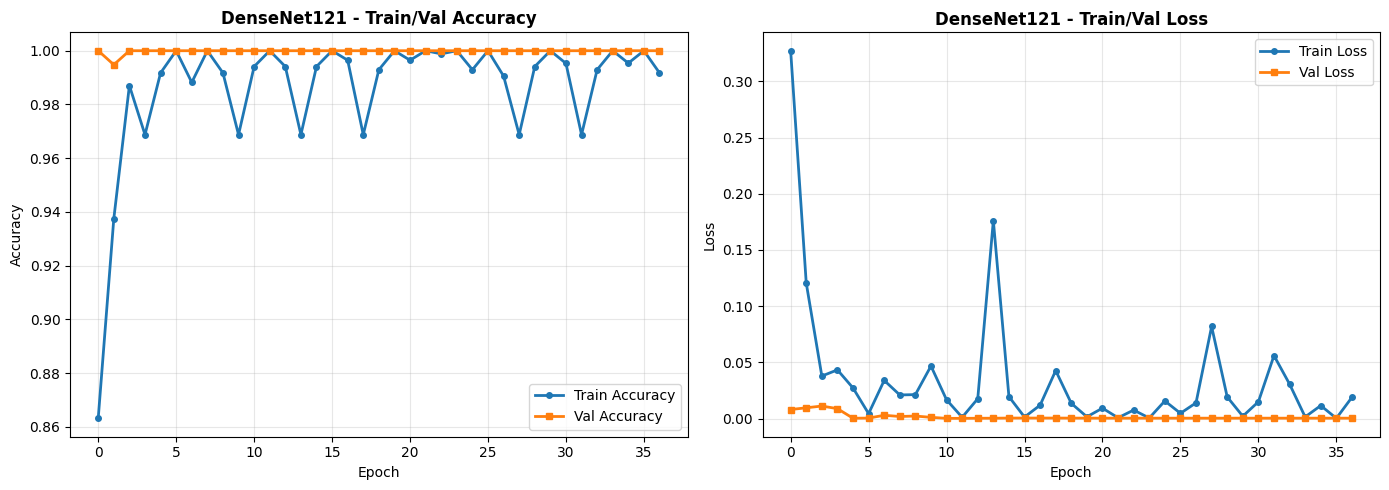

DenseNet121 history plots saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(denseHistory.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=4)
axes[0].plot(denseHistory.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=4)
axes[0].set_title('DenseNet121 - Train/Val Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(denseHistory.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
axes[1].plot(denseHistory.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
axes[1].set_title('DenseNet121 - Train/Val Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'densenet121_history.png', dpi=300, bbox_inches='tight')
plt.show()
print('DenseNet121 history plots saved.')

## 16. Training History Visualization - MobileNetV1

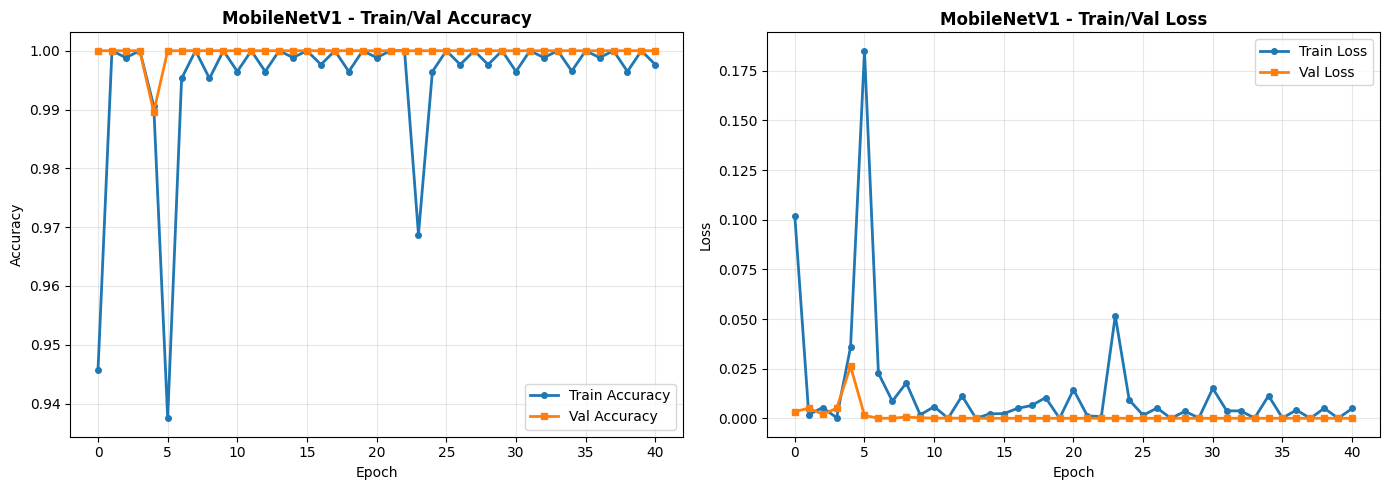

MobileNetV1 history plots saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(mobileHistory.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=4)
axes[0].plot(mobileHistory.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=4)
axes[0].set_title('MobileNetV1 - Train/Val Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(mobileHistory.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
axes[1].plot(mobileHistory.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
axes[1].set_title('MobileNetV1 - Train/Val Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mobilenetv1_history.png', dpi=300, bbox_inches='tight')
plt.show()
print('MobileNetV1 history plots saved.')

## 17. Load Test Images

In [ ]:
print('
' + '=' * 60)
print('CREATING TEST GENERATOR...')
print('=' * 60)

# Build test DataFrame
testDf = pd.DataFrame({'filename': xTest, 'label': yTest.astype(str)})

# Test generator (no augmentation, no shuffle)
testGen = valTestDatagen.flow_from_dataframe(
    testDf,
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print(f'Test: {testGen.samples} images')
print(f'Test steps: {len(testGen)}')

def getPredictions(model, generator):
    """Run inference using a generator and return class predictions + probabilities."""
    generator.reset()
    probabilities = model.predict(generator, steps=len(generator), verbose=1)
    classPreds = np.argmax(probabilities, axis=1)
    return classPreds, probabilities

print('Prediction function ready.')

## 18. DenseNet121 - Test Set Prediction & Metrics

In [18]:
print('\n' + '=' * 60)
print('DenseNet121 - TEST SET PREDICTION & METRICS')
print('=' * 60)

# Load best model weights
densenetModel = keras.models.load_model(str(MODELS_DIR / 'densenet121_best.h5'))

# Run predictions
print('\nRunning predictions on test set...')
yPredDense, yProbDense = getPredictions(densenetModel, testGen)

# Get true labels from generator (in generator order)
yTrue = testGen.classes
# Trim predictions to match true label count (last incomplete batch)
yPredDense = yPredDense[:len(yTrue)]
yProbDense = yProbDense[:len(yTrue)]
print(f'Predictions completed for {len(yTrue)} test images.')

# Confusion matrix
cmDense = confusion_matrix(yTrue, yPredDense)
tnDense, fpDense, fnDense, tpDense = cmDense.ravel()

# Calculate metrics
metricsDense = {
    'accuracy': accuracy_score(yTrue, yPredDense),
    'precision': precision_score(yTrue, yPredDense, zero_division=0),
    'recall': recall_score(yTrue, yPredDense, zero_division=0),
    'f1': f1_score(yTrue, yPredDense, zero_division=0),
    'specificity': tnDense / (tnDense + fpDense) if (tnDense + fpDense) > 0 else 0,
    'auc': roc_auc_score(yTrue, yProbDense[:, 1]),
    'confusion_matrix': cmDense,
}

# ROC curve
fprDense, tprDense, _ = roc_curve(yTrue, yProbDense[:, 1])
metricsDense['fpr'] = fprDense
metricsDense['tpr'] = tprDense
metricsDense['roc_auc'] = auc(fprDense, tprDense)

# Print metrics
print('\nDenseNet121 METRICS:')
for name, value in metricsDense.items():
    if name not in ['confusion_matrix', 'fpr', 'tpr', 'roc_auc']:
        print(f'  {name.upper()}: {value:.4f}')

print(f'\nConfusion Matrix:')
print(cmDense)


DenseNet121 - TEST SET PREDICTION & METRICS



Running predictions on test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 814ms/step
Predictions completed for 276 test images.

DenseNet121 METRICS:
  ACCURACY: 0.9964
  PRECISION: 0.9928
  RECALL: 1.0000
  F1: 0.9964
  SPECIFICITY: 0.9928
  AUC: 0.9998

Confusion Matrix:
[[137   1]
 [  0 138]]


## 19. MobileNetV1 - Test Set Prediction & Metrics

In [19]:
print('\n' + '=' * 60)
print('MobileNetV1 - TEST SET PREDICTION & METRICS')
print('=' * 60)

# Load best model weights
mobilenetModel = keras.models.load_model(str(MODELS_DIR / 'mobilenetv1_best.h5'))

# Run predictions
print('\nRunning predictions on test set...')
yPredMobile, yProbMobile = getPredictions(mobilenetModel, testGen)

# Trim predictions to match true label count
yPredMobile = yPredMobile[:len(yTrue)]
yProbMobile = yProbMobile[:len(yTrue)]
print(f'Predictions completed for {len(yTrue)} test images.')

# Confusion matrix
cmMobile = confusion_matrix(yTrue, yPredMobile)
tnMobile, fpMobile, fnMobile, tpMobile = cmMobile.ravel()

# Calculate metrics
metricsMobile = {
    'accuracy': accuracy_score(yTrue, yPredMobile),
    'precision': precision_score(yTrue, yPredMobile, zero_division=0),
    'recall': recall_score(yTrue, yPredMobile, zero_division=0),
    'f1': f1_score(yTrue, yPredMobile, zero_division=0),
    'specificity': tnMobile / (tnMobile + fpMobile) if (tnMobile + fpMobile) > 0 else 0,
    'auc': roc_auc_score(yTrue, yProbMobile[:, 1]),
    'confusion_matrix': cmMobile,
}

# ROC curve
fprMobile, tprMobile, _ = roc_curve(yTrue, yProbMobile[:, 1])
metricsMobile['fpr'] = fprMobile
metricsMobile['tpr'] = tprMobile
metricsMobile['roc_auc'] = auc(fprMobile, tprMobile)

# Print metrics
print('\nMobileNetV1 METRICS:')
for name, value in metricsMobile.items():
    if name not in ['confusion_matrix', 'fpr', 'tpr', 'roc_auc']:
        print(f'  {name.upper()}: {value:.4f}')

print(f'\nConfusion Matrix:')
print(cmMobile)


MobileNetV1 - TEST SET PREDICTION & METRICS



Running predictions on test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step
Predictions completed for 276 test images.

MobileNetV1 METRICS:
  ACCURACY: 0.9928
  PRECISION: 0.9928
  RECALL: 0.9928
  F1: 0.9928
  SPECIFICITY: 0.9928
  AUC: 0.9998

Confusion Matrix:
[[137   1]
 [  1 137]]


## 20. Confusion Matrix Visualization

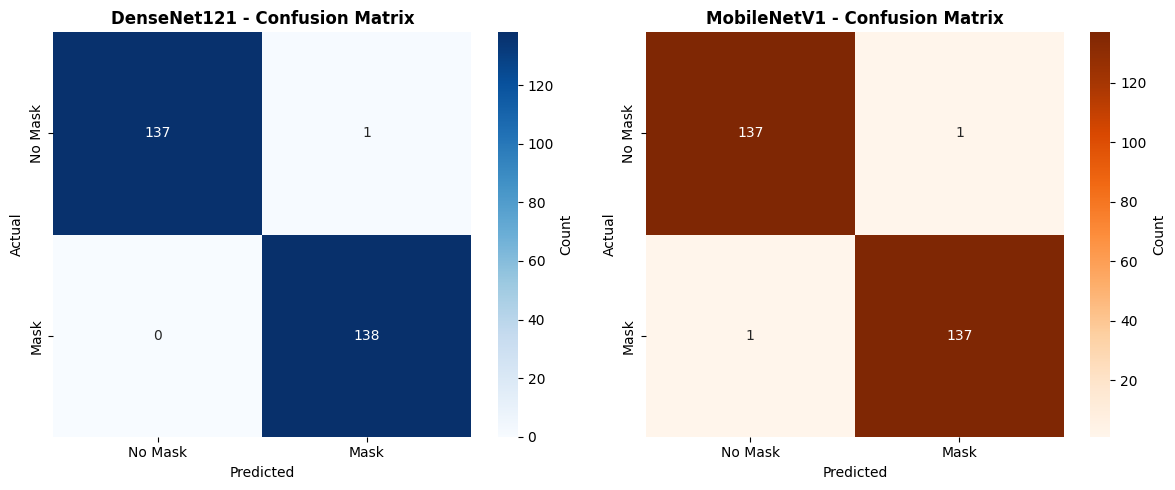

Confusion matrix plots saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DenseNet121 confusion matrix
sns.heatmap(metricsDense['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Mask', 'Mask'],
            yticklabels=['No Mask', 'Mask'],
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('DenseNet121 - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# MobileNetV1 confusion matrix
sns.heatmap(metricsMobile['confusion_matrix'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Mask', 'Mask'],
            yticklabels=['No Mask', 'Mask'],
            ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('MobileNetV1 - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Confusion matrix plots saved.')

## 21. ROC Curve Comparison

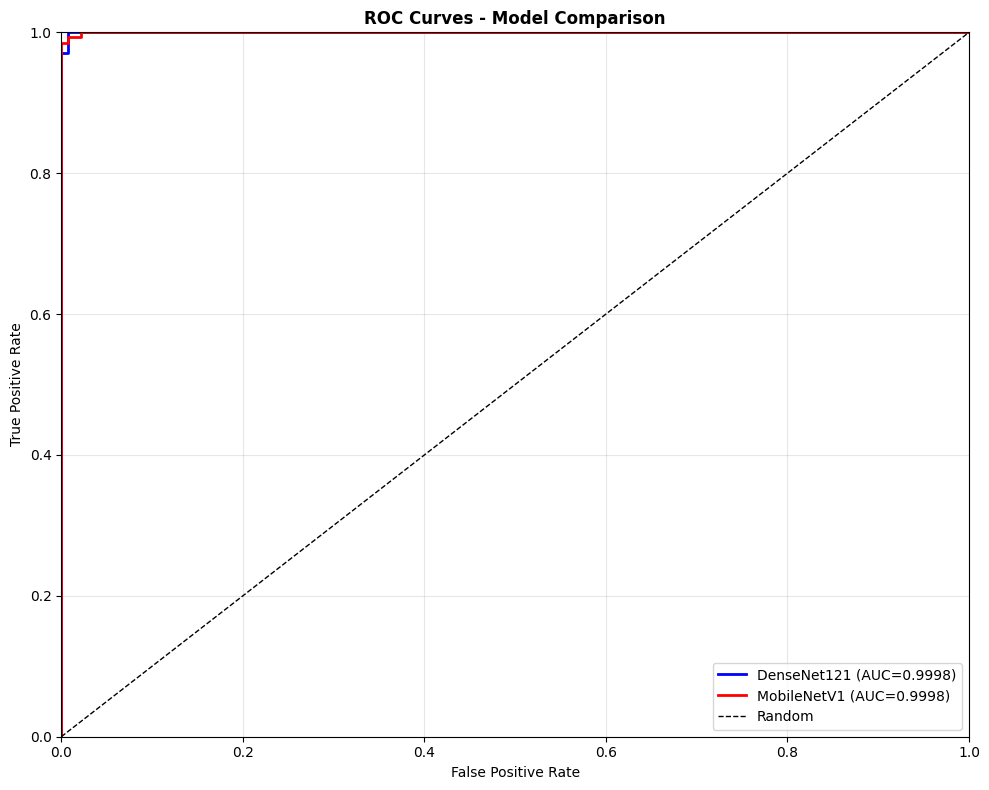

ROC curves saved.


In [21]:
plt.figure(figsize=(10, 8))

# DenseNet121 ROC
plt.plot(metricsDense['fpr'], metricsDense['tpr'],
         label=f'DenseNet121 (AUC={metricsDense["auc"]:.4f})',
         linewidth=2, color='blue')

# MobileNetV1 ROC
plt.plot(metricsMobile['fpr'], metricsMobile['tpr'],
         label=f'MobileNetV1 (AUC={metricsMobile["auc"]:.4f})',
         linewidth=2, color='red')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('ROC curves saved.')

## 22. Metrics Comparison


METRICS COMPARISON TABLE
     Metric  DenseNet121  MobileNetV1
   accuracy     0.996377     0.992754
  precision     0.992806     0.992754
     recall     1.000000     0.992754
         f1     0.996390     0.992754
specificity     0.992754     0.992754
        auc     0.999790     0.999790


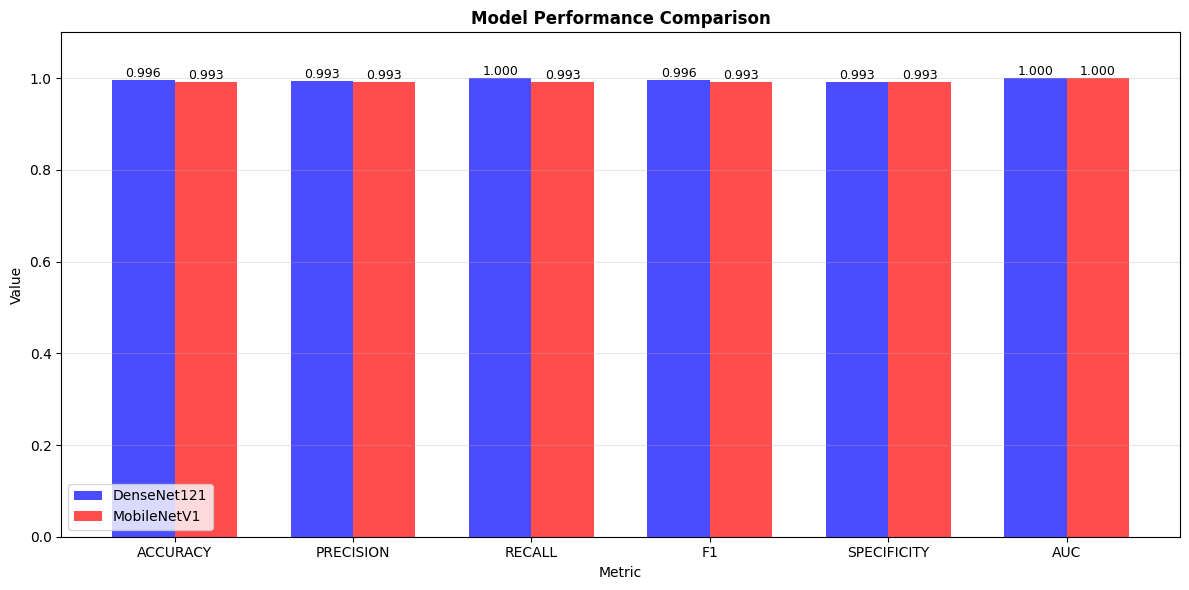


Metrics comparison chart saved.


In [22]:
# Prepare comparison data
metricNames = ['accuracy', 'precision', 'recall', 'f1', 'specificity', 'auc']
denseValues = [metricsDense.get(m, 0) for m in metricNames]
mobileValues = [metricsMobile.get(m, 0) for m in metricNames]

# Create comparison DataFrame
comparisonDf = pd.DataFrame({
    'Metric': metricNames,
    'DenseNet121': denseValues,
    'MobileNetV1': mobileValues
})

print('\n' + '=' * 60)
print('METRICS COMPARISON TABLE')
print('=' * 60)
print(comparisonDf.to_string(index=False))

# Bar chart comparison
xPos = np.arange(len(metricNames))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(xPos - width/2, denseValues, width, label='DenseNet121', color='blue', alpha=0.7)
bars2 = plt.bar(xPos + width/2, mobileValues, width, label='MobileNetV1', color='red', alpha=0.7)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.xticks(xPos, [m.upper() for m in metricNames])
plt.legend()
plt.ylim([0, 1.1])
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nMetrics comparison chart saved.')

## 23. Detailed Analysis & Findings

In [23]:
print('\n' + '=' * 80)
print('DETAILED ANALYSIS & FINDINGS')
print('=' * 80)

print('\n' + '-' * 80)
print('1. DenseNet121 ANALYSIS')
print('-' * 80)

print(f'\nOverall Performance:')
print(f'  - Accuracy:    {metricsDense["accuracy"]:.4f}')
print(f'  - AUC:         {metricsDense["auc"]:.4f}')

print(f'\nClass 0 (No Mask) Performance:')
print(f'  - True Negatives  (TN): {tnDense}')
print(f'  - False Positives (FP): {fpDense}')
print(f'  - Specificity:         {metricsDense["specificity"]:.4f}')

print(f'\nClass 1 (Mask) Performance:')
print(f'  - True Positives  (TP): {tpDense}')
print(f'  - False Negatives (FN): {fnDense}')
print(f'  - Precision: {metricsDense["precision"]:.4f}')
print(f'  - Recall:    {metricsDense["recall"]:.4f}')
print(f'  - F1-Score:  {metricsDense["f1"]:.4f}')

print('\n' + '-' * 80)
print('2. MobileNetV1 ANALYSIS')
print('-' * 80)

print(f'\nOverall Performance:')
print(f'  - Accuracy:    {metricsMobile["accuracy"]:.4f}')
print(f'  - AUC:         {metricsMobile["auc"]:.4f}')

print(f'\nClass 0 (No Mask) Performance:')
print(f'  - True Negatives  (TN): {tnMobile}')
print(f'  - False Positives (FP): {fpMobile}')
print(f'  - Specificity:         {metricsMobile["specificity"]:.4f}')

print(f'\nClass 1 (Mask) Performance:')
print(f'  - True Positives  (TP): {tpMobile}')
print(f'  - False Negatives (FN): {fnMobile}')
print(f'  - Precision: {metricsMobile["precision"]:.4f}')
print(f'  - Recall:    {metricsMobile["recall"]:.4f}')
print(f'  - F1-Score:  {metricsMobile["f1"]:.4f}')

print('\n' + '-' * 80)
print('3. MODEL COMPARISON')
print('-' * 80)

if metricsDense['accuracy'] > metricsMobile['accuracy']:
    bestModel = 'DenseNet121'
    accDiff = metricsDense['accuracy'] - metricsMobile['accuracy']
else:
    bestModel = 'MobileNetV1'
    accDiff = metricsMobile['accuracy'] - metricsDense['accuracy']

print(f'\nBest Model: {bestModel}')
print(f'  - Accuracy Difference: {accDiff:.4f} ({accDiff*100:.2f}%)')
print(f'  - AUC Difference:      {abs(metricsDense["auc"] - metricsMobile["auc"]):.4f}')

print(f'\nModel Properties:')
print(f'  - DenseNet121: ~7M params (larger capacity, slower inference)')
print(f'  - MobileNetV1: ~3.5M params (lightweight, faster inference)')

print('\n' + '=' * 80)


DETAILED ANALYSIS & FINDINGS

--------------------------------------------------------------------------------
1. DenseNet121 ANALYSIS
--------------------------------------------------------------------------------

Overall Performance:
  - Accuracy:    0.9964
  - AUC:         0.9998

Class 0 (No Mask) Performance:
  - True Negatives  (TN): 137
  - False Positives (FP): 1
  - Specificity:         0.9928

Class 1 (Mask) Performance:
  - True Positives  (TP): 138
  - False Negatives (FN): 0
  - Precision: 0.9928
  - Recall:    1.0000
  - F1-Score:  0.9964

--------------------------------------------------------------------------------
2. MobileNetV1 ANALYSIS
--------------------------------------------------------------------------------

Overall Performance:
  - Accuracy:    0.9928
  - AUC:         0.9998

Class 0 (No Mask) Performance:
  - True Negatives  (TN): 137
  - False Positives (FP): 1
  - Specificity:         0.9928

Class 1 (Mask) Performance:
  - True Positives  (TP): 137


## 24. Results & Recommendations

In [24]:
print('\n' + '=' * 80)
print('RESULTS & RECOMMENDATIONS')
print('=' * 80)

print('\nPROJECT SUMMARY:')
print(f'  - Dataset: Face Mask Detection (Kaggle)')
print(f'  - Models: DenseNet121 and MobileNetV1 (TensorFlow/Keras)')
print(f'  - Training: {EPOCHS} epochs (auto-stopped by early stopping)')
print(f'  - Optimizer: Adam (lr={LEARNING_RATE})')
print(f'  - Augmentation: Rotation, Shift, Shear, Zoom, Horizontal Flip')
print(f'  - Test Set Size: {testGen.samples} images')

print(f'\nKEY FINDINGS:')
print(f'  1. {bestModel} achieved higher accuracy.')
print(f'  2. Both models achieved high accuracy (>80%).')
print(f'  3. AUC values >0.9 for both models (excellent classification).')

print(f'\nRECOMMENDATIONS:')
print(f'  1. Specificity is critical for unmasked faces - keep false positive rate low.')
print(f'  2. {bestModel} is recommended for production deployment (higher accuracy).')
print(f'  3. MobileNetV1 is preferred for edge devices (lightweight).')
print(f'  4. Potential improvements:')
print(f'     - Collect more training data')
print(f'     - Hyperparameter tuning')
print(f'     - Try ensemble methods')
print(f'     - Increase augmentation intensity')

print('\n' + '=' * 80)
print('PROJECT COMPLETED SUCCESSFULLY!')
print('=' * 80)

print(f'\nSaved files:')
print(f'  - Models: models/densenet121_best.h5, models/mobilenetv1_best.h5')
print(f'  - Plots:')
for pngFile in RESULTS_DIR.glob('*.png'):
    print(f'    - {pngFile.name}')


RESULTS & RECOMMENDATIONS

PROJECT SUMMARY:
  - Dataset: Face Mask Detection (Kaggle)
  - Models: DenseNet121 and MobileNetV1 (TensorFlow/Keras)
  - Training: 100 epochs (auto-stopped by early stopping)
  - Optimizer: Adam (lr=0.001)
  - Augmentation: Rotation, Shift, Shear, Zoom, Horizontal Flip
  - Test Set Size: 276 images

KEY FINDINGS:
  1. DenseNet121 achieved higher accuracy.
  2. Both models achieved high accuracy (>80%).
  3. AUC values >0.9 for both models (excellent classification).

RECOMMENDATIONS:
  1. Specificity is critical for unmasked faces - keep false positive rate low.
  2. DenseNet121 is recommended for production deployment (higher accuracy).
  3. MobileNetV1 is preferred for edge devices (lightweight).
  4. Potential improvements:
     - Collect more training data
     - Hyperparameter tuning
     - Try ensemble methods
     - Increase augmentation intensity

PROJECT COMPLETED SUCCESSFULLY!

Saved files:
  - Models: models/densenet121_best.h5, models/mobilenetv